In [1]:
!git clone https://github.com/PeterL1n/RobustVideoMatting.git
%cd RobustVideoMatting

# Ensure git-lfs is installed and fetch large files
!git lfs install
!git lfs pull
!ls -lh

Cloning into 'RobustVideoMatting'...
remote: Enumerating objects: 211, done.
remote: Total 211 (delta 0), reused 0 (delta 0), pack-reused 211 (from 1)
Receiving objects: 100% (211/211), 9.00 MiB | 10.61 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/RobustVideoMatting
Updated git hooks.
Git LFS initialized.
total 144K
drwxr-xr-x 2 root root 4.0K Mar 29 02:37 dataset
drwxr-xr-x 4 root root 4.0K Mar 29 02:37 documentation
drwxr-xr-x 2 root root 4.0K Mar 29 02:37 evaluation
-rw-r--r-- 1 root root 1.3K Mar 29 02:37 hubconf.py
-rw-r--r-- 1 root root 8.6K Mar 29 02:37 inference.py
-rw-r--r-- 1 root root 1.7K Mar 29 02:37 inference_speed_test.py
-rw-r--r-- 1 root root 2.7K Mar 29 02:37 inference_utils.py
-rw-r--r-- 1 root root  35K Mar 29 02:37 LICENSE
drwxr-xr-x 2 root root 4.0K Mar 29 02:37 model
-rw-r--r-- 1 root root  13K Mar 29 02:37 README.md
-rw-r--r-- 1 root root  12K Mar 29 02:37 README_zh_Hans.md
-rw-r--r-- 1 root root   65 Mar 29 02:37 requirements_inference.txt
-rw-r-

In [2]:
%cd /content/RobustVideoMatting

# Download MobileNetV3 weights directly from GitHub release
!wget -O rvm_mobilenetv3.pth \
  https://github.com/PeterL1n/RobustVideoMatting/releases/download/v1.0/rvm_mobilenetv3.pth

!ls -lh rvm_mobilenetv3.pth

/content/RobustVideoMatting
--2026-03-29 02:37:09--  https://github.com/PeterL1n/RobustVideoMatting/releases/download/v1.0/rvm_mobilenetv3.pth
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-29 02:37:09 ERROR 404: Not Found.

-rw-r--r-- 1 root root 0 Mar 29 02:37 rvm_mobilenetv3.pth


In [3]:
%cd /content/RobustVideoMatting

# Download the official PyTorch MobileNetV3 weights
!wget -O rvm_mobilenetv3.pth \
  https://github.com/PeterL1n/RobustVideoMatting/releases/download/v1.0.0/rvm_mobilenetv3.pth

!ls -lh rvm_mobilenetv3.pth

/content/RobustVideoMatting
--2026-03-29 02:37:09--  https://github.com/PeterL1n/RobustVideoMatting/releases/download/v1.0.0/rvm_mobilenetv3.pth
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/401484223/2e078df8-55cc-4d11-8afe-764dc6c65c70?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-29T03%3A14%3A09Z&rscd=attachment%3B+filename%3Drvm_mobilenetv3.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-29T02%3A13%3A31Z&ske=2026-03-29T03%3A14%3A09Z&sks=b&skv=2018-11-09&sig=G1ZZ2rqGFvgr%2FkrTavYb78GvVpZsP4OexWqqRSQw0sg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDc1MzYzMCwibmJmIjoxNzc0NzUxODMw

In [4]:
import torch
from model import MattingNetwork

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MattingNetwork('mobilenetv3').eval().to(device)
state_dict = torch.load('rvm_mobilenetv3.pth', map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [5]:
!pwd

/content/RobustVideoMatting


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
dataset_path = '/content/drive/MyDrive/CV/VideoMatte240K_JPEG_SD/train'

In [8]:
import os
import glob
import cv2
import numpy as np

class VideoMatteDatasetHelper:
    """
    Helper to load VideoMatte240K dataset sequences.

    Expected directory structure (for a given split, e.g., 'train'):

        root_dir/
            fgr/
                0001/
                    00000.jpg
                    00001.jpg
                    ...
                0002/
                    ...
            pha/
                0001/
                    00000.png
                    00001.png
                    ...
                0002/
                    ...

    For a given sequence_name (e.g., '0007'), this helper:
      - reads foreground RGB frames from fgr/sequence_name
      - reads alpha mattes from pha/sequence_name
      - synthesizes a "source video" by compositing FG onto a solid-color BG
      - returns (synthetic_frames, alpha_masks)
    """

    def __init__(self, root_dir: str):
        """
        Args:
            root_dir: path to the split root, e.g.
                      '/content/drive/MyDrive/CV/VideoMatte240K_JPEG_SD/train'
        """
        self.root_dir = root_dir

    def load_sequence(self, sequence_name: str, bg_color=(0, 255, 0)):
        """
        Load a sequence and synthesize a source video over a solid background.

        Args:
            sequence_name: e.g., '0007'
            bg_color: tuple (R, G, B) or (B, G, R) depending on convention.
                      Here we assume RGB and convert appropriately.

        Returns:
            synthetic_frames: list of HxWx3 uint8 RGB arrays
            masks:            list of HxW float32 alpha maps in [0,1]
        """
        fgr_dir = os.path.join(self.root_dir, 'fgr', sequence_name)
        pha_dir = os.path.join(self.root_dir, 'pha', sequence_name)

        if not os.path.exists(fgr_dir):
            print(f"[VideoMatteDatasetHelper] Warning: foreground dir {fgr_dir} not found.")
            return [], []

        # Collect and sort frame paths
        fgr_paths = sorted(glob.glob(os.path.join(fgr_dir, '*.*')))
        pha_paths = sorted(glob.glob(os.path.join(pha_dir, '*.*')))

        if len(fgr_paths) == 0 or len(pha_paths) == 0:
            print(f"[VideoMatteDatasetHelper] Warning: no frames found for {sequence_name}.")
            return [], []

        if len(fgr_paths) != len(pha_paths):
            print(f"[VideoMatteDatasetHelper] Warning: FG ({len(fgr_paths)}) "
                  f"and alpha ({len(pha_paths)}) counts mismatch for {sequence_name}.")

        synthetic_frames = []
        masks = []

        for f_path, a_path in zip(fgr_paths, pha_paths):
            # Read foreground as BGR, convert to RGB
            fgr_bgr = cv2.imread(f_path, cv2.IMREAD_COLOR)
            if fgr_bgr is None:
                continue
            fgr = cv2.cvtColor(fgr_bgr, cv2.COLOR_BGR2RGB)

            # Read alpha as grayscale [0,255], convert to float [0,1]
            alpha = cv2.imread(a_path, cv2.IMREAD_GRAYSCALE)
            if alpha is None:
                continue
            alpha = alpha.astype(np.float32) / 255.0  # HxW

            h, w = fgr.shape[:2]

            # Create solid-color background in RGB
            bg = np.zeros_like(fgr, dtype=np.uint8)
            bg[:] = bg_color  # assuming bg_color is (R,G,B)

            # Expand alpha to 3 channels
            alpha_3 = alpha[..., None]  # HxWx1

            # Synthetic source frame: person over solid background
            src_float = fgr.astype(np.float32) * alpha_3 + bg.astype(np.float32) * (1.0 - alpha_3)
            src = np.clip(src_float, 0, 255).astype(np.uint8)

            synthetic_frames.append(src)
            masks.append(alpha)

        return synthetic_frames, masks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found sequences: ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009']
Loaded 339 frames for sequence 0000
Frame shape: (432, 768, 3)
Alpha shape: (432, 768)


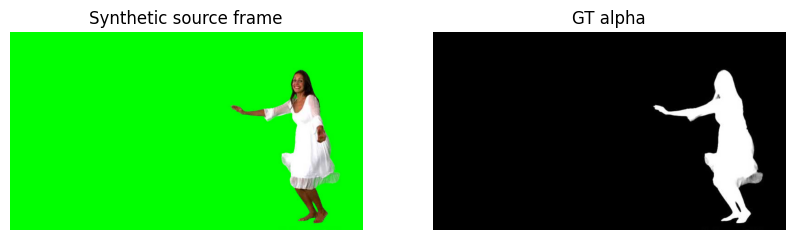

In [9]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Create the helper
train_root = '/content/drive/MyDrive/CV/VideoMatte240K_JPEG_SD/train'
videomatte_helper = VideoMatteDatasetHelper(train_root)

# 2. Inspect available sequences (folders under train/fgr)
import os
fgr_root = os.path.join(train_root, 'fgr')
sequence_names = sorted(os.listdir(fgr_root))
print("Found sequences:", sequence_names[:10])

# 3. Pick one sequence, e.g. the first
seq = sequence_names[0]   # e.g. '0007'

# 4. Load synthetic source frames and GT alpha masks
synthetic_frames, alpha_masks = videomatte_helper.load_sequence(
    sequence_name=seq,
    bg_color=(0, 255, 0)   # solid green background in RGB
)

def refine_alpha_list(alpha_list, k=9):
    refined = []
    for a in alpha_list:
        a_uint8 = (a * 255.0).astype(np.uint8)          # [0,255]
        a_blur = cv2.GaussianBlur(a_uint8, (k, k), 0)   # blur
        refined.append(a_blur.astype(np.float32) / 255.0)
    return refined

alpha_refined = refine_alpha_list(alpha_masks, k=9)

print(f"Loaded {len(synthetic_frames)} frames for sequence {seq}")
print("Frame shape:", synthetic_frames[0].shape)
print("Alpha shape:", alpha_masks[0].shape)

# 5. Visualize one pair to verify
import matplotlib.pyplot as plt

idx = 0
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Synthetic source frame"); plt.imshow(synthetic_frames[idx]); plt.axis('off')
plt.subplot(1,2,2); plt.title("GT alpha");              plt.imshow(alpha_masks[idx], cmap='gray'); plt.axis('off')
plt.show()

In [10]:
import cv2
import os

os.makedirs("videos", exist_ok=True)
video_path = "videos/videomatte_green.mp4"

# assume synthetic_frames is non-empty and RGB uint8
h, w = synthetic_frames[0].shape[:2]
fps = 25  # or 30, pick what you like

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(video_path, fourcc, fps, (w, h))

for frame in synthetic_frames:
    # frame is RGB, OpenCV expects BGR
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    writer.write(frame_bgr)

writer.release()
print("Saved video to:", video_path)

Saved video to: videos/videomatte_green.mp4


array([[[ 52,  60,  81],
        [  7,  15,  36],
        [ 30,  38,  61],
        ...,
        [171, 155, 121],
        [178, 162, 128],
        [181, 165, 131]],

       [[ 51,  58,  84],
        [ 32,  40,  63],
        [ 39,  46,  72],
        ...,
        [179, 163, 129],
        [176, 160, 126],
        [167, 151, 117]],

       [[ 27,  32,  64],
        [ 25,  30,  60],
        [ 25,  30,  59],
        ...,
        [179, 160, 128],
        [198, 179, 147],
        [182, 163, 131]],

       ...,

       [[110, 103,  75],
        [ 79,  71,  48],
        [ 60,  53,  34],
        ...,
        [ 85,  85,  73],
        [ 86,  85,  57],
        [123, 120,  85]],

       [[134, 121,  89],
        [146, 135, 103],
        [162, 153, 122],
        ...,
        [ 76,  69,  50],
        [106,  97,  64],
        [153, 144, 103]],

       [[157, 143, 108],
        [134, 121,  86],
        [131, 118,  83],
        ...,
        [156, 146, 121],
        [182, 169, 134],
        [193, 180, 136]]], dtype=uint8)
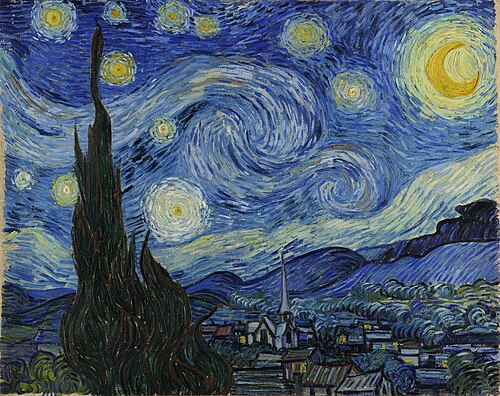

In [13]:
import cv2

background_ref = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/CV/background_photo.jpg'), cv2.COLOR_BGR2RGB)
background_ref

In [14]:
h, w = synthetic_frames[0].shape[:2]
background = cv2.resize(background_ref, (w, h))

array([[[155, 159, 170],
        [156, 160, 171],
        [157, 162, 172],
        ...,
        [140, 150, 160],
        [140, 150, 160],
        [140, 150, 160]],

       [[157, 161, 172],
        [157, 161, 172],
        [157, 161, 172],
        ...,
        [142, 152, 162],
        [142, 152, 162],
        [141, 151, 161]],

       [[158, 162, 173],
        [157, 160, 172],
        [156, 160, 171],
        ...,
        [141, 151, 161],
        [140, 150, 160],
        [140, 150, 160]],

       ...,

       [[ 46,  50,  51],
        [ 47,  51,  52],
        [ 44,  48,  49],
        ...,
        [ 31,  40,  39],
        [ 31,  40,  39],
        [ 32,  41,  40]],

       [[ 37,  39,  38],
        [ 35,  37,  36],
        [ 37,  39,  38],
        ...,
        [ 29,  35,  35],
        [ 29,  35,  35],
        [ 29,  35,  35]],

       [[ 33,  34,  36],
        [ 38,  39,  41],
        [ 38,  39,  41],
        ...,
        [ 29,  35,  35],
        [ 29,  35,  35],
        [ 30,  36,  36]]], dtype=uint8)
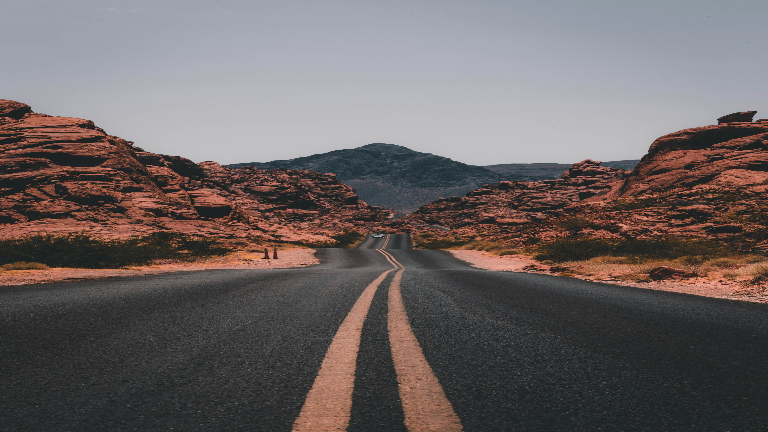

In [18]:
import urllib.request, cv2

url = "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?auto=format&fit=crop&w=1920&q=80"
# If that id is wrong, replace with the exact images.unsplash.com URL from the browser

urllib.request.urlretrieve(url, "forest_bg.jpg")
background = cv2.cvtColor(cv2.imread("forest_bg.jpg"), cv2.COLOR_BGR2RGB)

h, w = synthetic_frames[0].shape[:2]
background = cv2.resize(background, (w, h))
background

In [19]:
from diffusers import StableDiffusionImg2ImgPipeline
import torch
from PIL import Image
import numpy as np

def diffusion_guided_background_transfer(
    bg_rgb: np.ndarray,
    prompt: str = "",
    strength: float = 0.3,
    guidance_scale: float = 2.0,
    num_steps: int = 30,
    seed: int = 42,
    device: str = "cuda",
):
    """
    Diffusion-guided transform of a background image using SD v1.5 img2img.

    Args:
        bg_rgb:        HxWx3 uint8 RGB background image (content to be transformed).
        prompt:        Text prompt steering the style (can be empty).
        strength:      How far to move from bg_rgb (0.0 ~ identical, 1.0 ~ re-draw).
        guidance_scale:Classifier-free guidance; low when relying mostly on the image.
        num_steps:     Diffusion steps.
        seed:          Random seed for reproducibility.
        device:        "cuda" or "cpu".

    Returns:
        B_prime:       HxWx3 uint8 RGB, diffusion-transformed background.
    """
    model_id = "runwayml/stable-diffusion-v1-5"

    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    ).to(device)

    # Prepare init image for SD (512x512 typical)
    init_image = Image.fromarray(bg_rgb).convert("RGB").resize((512, 512))
    generator = torch.Generator(device).manual_seed(seed)

    result = pipe(
        prompt=prompt,
        image=init_image,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=num_steps,
        generator=generator,
    )
    img_out = result.images[0]

    # Resize back to original resolution
    B_prime = np.array(img_out.resize((bg_rgb.shape[1], bg_rgb.shape[0])))

    del pipe
    if device == "cuda":
        torch.cuda.empty_cache()

    return B_prime

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [20]:
B_prime = diffusion_guided_background_transfer(
    background,
    prompt="",
    strength=0.3,
    guidance_scale=2.0,
    num_steps=30,
    seed=42,
    device="cuda",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/9 [00:00<?, ?it/s]

In [21]:
composited_frames = []
tau = 10.0 / 255.0   # paste-back threshold

for F_t, a_raw_t, a_ref_t in zip(synthetic_frames, alpha_masks, alpha_refined):
    # --- 4a: alpha blend with refined alpha ---
    a = a_ref_t[..., None]                     # HxWx1
    F_float = F_t.astype(np.float32)
    B_float = B_prime.astype(np.float32)
    C_blend = F_float * a + B_float * (1.0 - a)

    # --- 4b: foreground paste-back with raw alpha ---
    mask = (a_raw_t > tau)[..., None]          # interior FG
    C_paste = np.where(mask, F_float, C_blend)

    C = np.clip(C_paste, 0, 255).astype(np.uint8)
    composited_frames.append(C)

In [22]:
len(composited_frames)

339

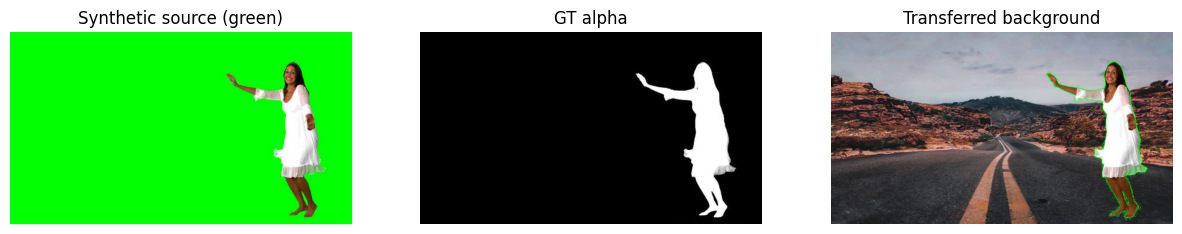

In [23]:
import matplotlib.pyplot as plt

idx = 4
plt.figure(figsize=(15,4))
plt.subplot(1,3,1); plt.title("Synthetic source (green)"); plt.imshow(synthetic_frames[idx]); plt.axis('off')
plt.subplot(1,3,2); plt.title("GT alpha");                 plt.imshow(alpha_masks[idx], cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Transferred background");   plt.imshow(composited_frames[idx]); plt.axis('off')
plt.show()

In [24]:
import os

os.makedirs("videos", exist_ok=True)
bg_transfer_path = "videos/videomatte_bg_transfer_gt_alpha.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(bg_transfer_path, fourcc, 25, (w, h))

for frame in composited_frames:
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    writer.write(frame_bgr)

writer.release()
print("Saved transferred video to:", bg_transfer_path)

Saved transferred video to: videos/videomatte_bg_transfer_gt_alpha.mp4
